#Day 30 - Prediksi Korban Selamat Kapal Titanic

Salah satu proyek paling ikonik di dunia Machine Learning: memprediksi **siapa yang selamat** dari tragedi Titanic berdasarkan data penumpang. Notebook ini menggabungkan **feature engineering** (membuat fitur baru yang berguna) dengan **klasifikasi**.

> 🎯 **Tujuan Pembelajaran**
> - Melakukan **feature engineering**: `Sex`, `Pclass`, `Age`, `FamilySize`, `Embarked`.
> - **Encode** fitur kategori menjadi angka.
> - Melatih model klasifikasi (**Logistic Regression** & **Random Forest**).
> - Mengevaluasi dengan confusion matrix & classification_report serta membaca insight.

## Tentang Dataset

**Titanic Dataset** berisi data penumpang kapal Titanic. Target: **`Survived`**
(1 = selamat, 0 = tidak).

- **Sumber:** [Kaggle — yasserh/titanic-dataset](https://www.kaggle.com/datasets/yasserh/titanic-dataset)

| Kolom | Arti |
|-------|------|
| `Survived` | **(Target)** 1 = selamat, 0 = meninggal |
| `Pclass` | Kelas tiket (1/2/3) |
| `Sex` | Jenis kelamin |
| `Age` | Usia (banyak yang kosong) |
| `SibSp` | Jumlah saudara/pasangan di kapal |
| `Parch` | Jumlah orang tua/anak di kapal |
| `Fare` | Tarif tiket |
| `Embarked` | Pelabuhan keberangkatan (C/Q/S) |

## Import Library

- **pandas / numpy** → olah data & feature engineering.
- **matplotlib / seaborn** → visualisasi.
- **scikit-learn** → `LogisticRegression`, `RandomForestClassifier`, scaling,
  split, dan metrik klasifikasi.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay

In [39]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [40]:
!pip install kaggle
!kaggle datasets download -d yasserh/titanic-dataset
!unzip titanic-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/yasserh/titanic-dataset
License(s): CC0-1.0
titanic-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  titanic-dataset.zip
replace Titanic-Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Titanic-Dataset.csv     


## Import Dataset

In [41]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Interpretasi:
- Setiap baris mewakili 1 entitas penumpang

## Eksplorasi Awal Dataset

In [42]:
# Menampilkan informasi umum dataset (tipe data, non-null count, dimensi)
print("=== Informasi Dataset ===")
df.info()

# Menampilkan statistik deskriptif dataset
print("\n=== Statistik Deskriptif ===")
df.describe()

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== Statistik Deskriptif ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [43]:
# Menampilkan Data yang hilang
print("\n=== Missing Value ===")
df.isnull().sum()


=== Missing Value ===


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Interpretasi:
-   `Age` banyak yang kosong,
- `Cabin` hampir seluruhnya kosong, dan `Embarked` punya sedikit missing.

Kita akan imputasi `Age` & `Embarked`, dan membuang `Cabin`.

In [44]:
df['Survived'].value_counts(normalize=True).round(2)*100

,proportion
Survived,
0,62.0
1,38.0


Interpretasi:
- Sekitar 38% Penumpang Berhasil selamat
- Target Imbalanced tapi masih kategori wajar

## Cleaning Data

Langkah inti notebook ini:
1. **`Age`** → isi missing dengan **median**.
2. **`Embarked`** → isi missing dengan **modus** (nilai terbanyak).
3. **`FamilySize`** → fitur baru = `SibSp + Parch + 1` (diri sendiri).
4. **`IsAlone`** → fitur baru = 1 bila bepergian sendirian.
5. **Encode** `Sex` (0/1) dan `Embarked` (one-hot).
6. Buang kolom yang tidak relevan (`Name`, `Ticket`, `Cabin`, `PassengerId`).

In [45]:
data = df.copy()

In [46]:
# 1) Age -> median
data['Age'] = data['Age'].fillna(data['Age'].median())

In [47]:
# 2) Embarked -> modus
data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [48]:
# 3) FamilySize & 4) IsAlone
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)

In [49]:
print("Missing tersisa pada kolom kunci:")
print(data[["Age", "Embarked", "FamilySize", "IsAlone"]].isnull().sum())
data[["Age", "SibSp", "Parch", "FamilySize", "IsAlone", "Embarked"]].head()

Missing tersisa pada kolom kunci:
Age           0
Embarked      0
FamilySize    0
IsAlone       0
dtype: int64


,Age,SibSp,Parch,FamilySize,IsAlone,Embarked
0,22.0,1,0,2,0,S
1,38.0,1,0,2,0,C
2,26.0,0,0,1,1,S
3,35.0,1,0,2,0,S
4,35.0,0,0,1,1,S


Interpretasi:
- `FamilySize` merangkum SibSp & Parch menjadi satu angka bermakna (besar keluarga di kapal), dan `IsAlone` menyederhanakannya jadi indikator biner. Keduanya sering lebih prediktif daripada kolom aslinya.

In [50]:
#5 Encode Sex (0=Female, 1=Male) dan embarked (One-Hot)
data['Sex'] = data['Sex'].map({'female': 0, 'male': 1})
data = pd.get_dummies(data, columns=['Embarked'], prefix=['Emb'])


In [51]:
# 6 Drop Kolom tidak relevan
drp_clm = ['Name', 'Ticket', 'Cabin', 'PassengerId']
data.drop(columns=drp_clm, inplace=True, errors='ignore')
data.head()

# Memperbaiki pengecekan kolom setelah One-Hot Encoding
print("Missing tersisa pada kolom kunci:")
emb_cols = [col for col in data.columns if col.startswith('Emb_')]
print(data[["Age", "FamilySize", "IsAlone"] + emb_cols].isnull().sum())

Missing tersisa pada kolom kunci:
Age           0
FamilySize    0
IsAlone       0
Emb_C         0
Emb_Q         0
Emb_S         0
dtype: int64


In [52]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Emb_C,Emb_Q,Emb_S
0,0,3,1,22.0,1,0,7.2500,2,0,False,False,True
1,1,1,0,38.0,1,0,71.2833,2,0,True,False,False
2,1,3,0,26.0,0,0,7.9250,1,1,False,False,True
3,1,1,0,35.0,1,0,53.1000,2,0,False,False,True
4,0,3,1,35.0,0,0,8.0500,1,1,False,False,True


Interpretasi:
  -  Semua fitur kini berupa angka. `Sex` jadi 0/1, `Embarked` dipecah menjadi beberapa kolom biner (one-hot). Data siap dimodelkan.

## Eksplorasi Data Analisis dan Visualisasi

### a) Tingkat Keselamatan berdasarkan Jenis Kelamin

/tmp/ipykernel_1088/2575798655.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette="Set2")


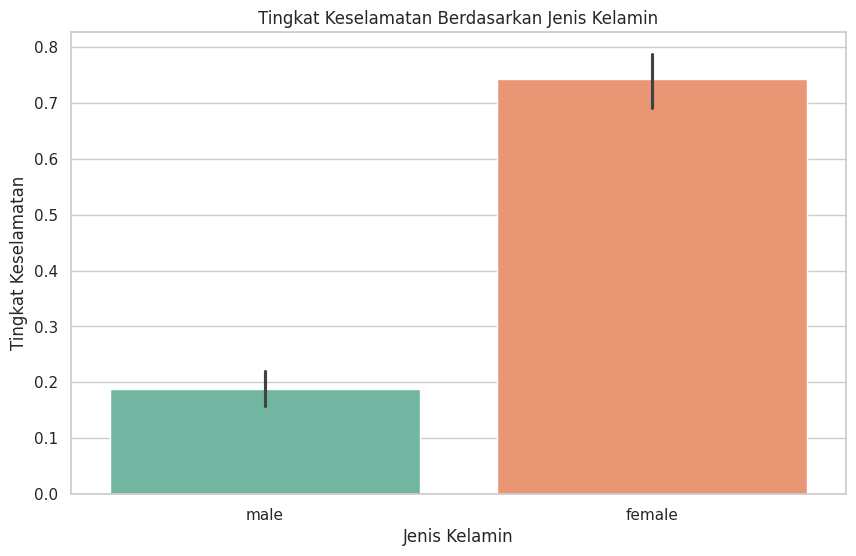

In [53]:
sns.barplot(data=df, x='Sex', y='Survived', palette="Set2")
plt.title('Tingkat Keselamatan Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Tingkat Keselamatan')
plt.show()

Interpretasi:
- Peluang jenis kelamin perempuan lebih besar selamat daripada laki laki
- bisa jadi menjelaskan kebijakan "Woman First and Childer First"

### b) Tingkat Keselamatan Berdasarkan Jenis Kelas Tiket

/tmp/ipykernel_1088/830030738.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette="Set2")


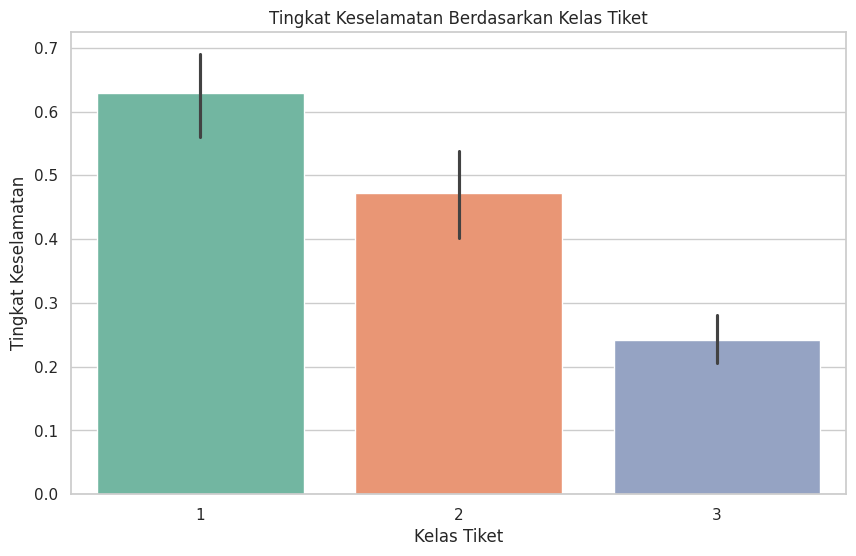

In [54]:
sns.barplot(data=df, x='Pclass', y='Survived', palette="Set2")
plt.title('Tingkat Keselamatan Berdasarkan Kelas Tiket')
plt.xlabel('Kelas Tiket')
plt.ylabel('Tingkat Keselamatan')
plt.show()

Interpretasi:
- Penumpang kelas 1, paling besar peluangnya untuk selamat.
- Penumpang kelas 3, paling kecil peluangnya
- Status Ekonomi dan Sosial Berpengaruh

### c) Distribusi Usia Berdasarkan Keselamatan

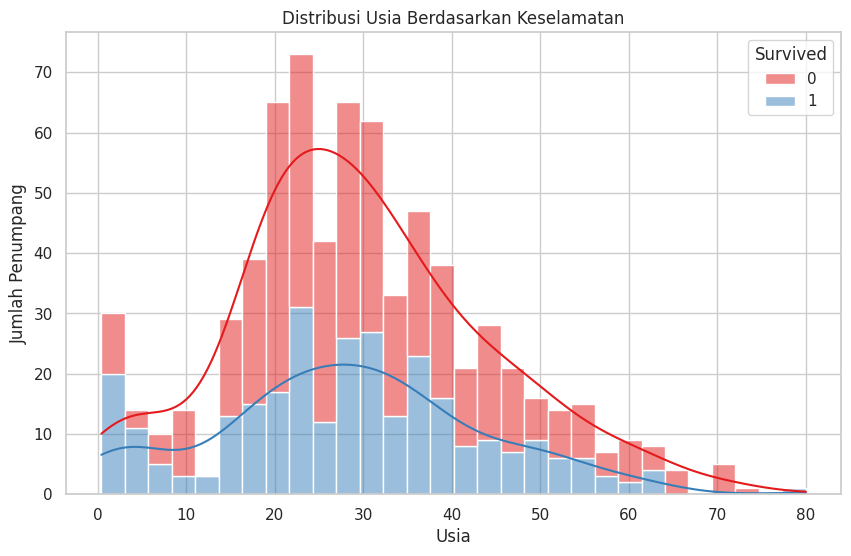

In [55]:
sns.histplot(data=df, x='Age', hue='Survived', multiple='stack', palette="Set1", bins=30, kde=True)
plt.title('Distribusi Usia Berdasarkan Keselamatan')
plt.xlabel('Usia')
plt.ylabel('Jumlah Penumpang')
plt.show()

Interpretasi:
-  Anak-anak (usia sangat muda) tampak punya proporsi selamat lebih tinggi, mendukung gagasan 'children first'.

## Preprocessing : Split dan Scaling

1. Pisahkan Fitur dan Target, bagi dengan proporsi 80:20 dengan Stratify
2. Standarisasi untuk Logistic Regression

In [56]:
#1. Pisahkan Fitur dan Target, lalu bagi untuk data latih dan data test

X = data.drop(columns=['Survived'])
y = data['Survived']


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

In [57]:
#2 Standarisasi gunakan standarscaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   #Fit hanya untuk data latih
X_test_scaled = scaler.transform(X_test)         #Data test hanya di transform

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (712, 11)
X_test shape: (179, 11)


Interpretasi:

- 🔑 **Anti-bocor:** scaler di-`fit` **hanya pada data latih**, lalu data uji cukup di-`transform`.
- Ini menjaga evaluasi tetap jujur — data uji tak boleh ikut "mengajari" preprocessing.

## Modeling: Logistic Regression dan Random Forest

Kita latih 2 model dan membandingan performa keduanya:
  - LogisticRegression (Model Linear dan membutuhkan Scaling )
  - RandomForest ( Model Pohon Ensemble dan tidak membutuhkan Scaling )

In [58]:
#1 LogisticRegression Model gunakan data scaled
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)


In [60]:
#2 RandomForest Model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [63]:
print(f'Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}')
print(f'Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}')

Logistic Regression Accuracy: 0.804
Random Forest Accuracy: 0.799


Interpretasi:
- Logistic Regression Lebih unggul dalam akurasi

## Evaluasi Model

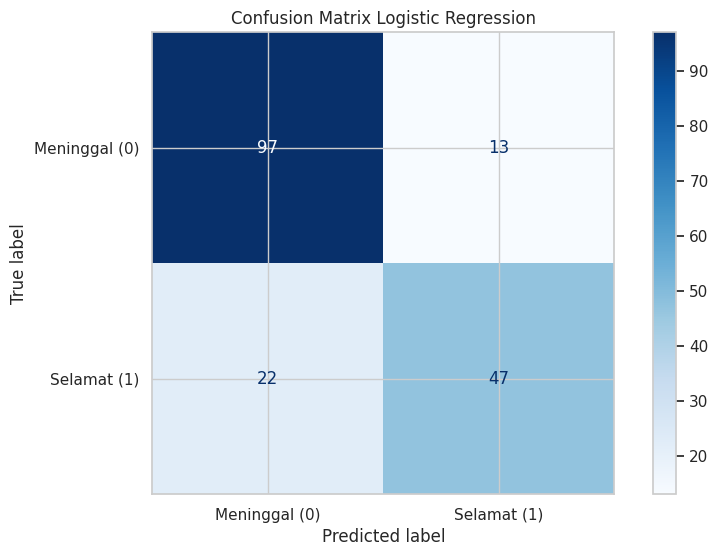

In [64]:
#Gunakan Confussion Metrik
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Meninggal (0)", "Selamat (1)"])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix Logistic Regression')
plt.show()

Interpretasi:

- Diagonal (kiri-atas & kanan-bawah) adalah prediksi benar.
- Sel kanan-atas = diprediksi selamat padahal meninggal;
- kiri-bawah = diprediksi meninggal padahal selamat.

Model umumnya seimbang dalam dua jenis kesalahan ini.

In [66]:
print(classification_report(y_test,
                            y_pred_lr,
                            target_names=["Meninggal (0)", "Selamat (1)"]))

               precision    recall  f1-score   support

Meninggal (0)       0.82      0.88      0.85       110
  Selamat (1)       0.78      0.68      0.73        69

     accuracy                           0.80       179
    macro avg       0.80      0.78      0.79       179
 weighted avg       0.80      0.80      0.80       179



Interpretasi:

- Akurasi Keseluruhan (0.80 atau 80%): Secara keseluruhan, model berhasil memprediksi status (meninggal atau selamat) dengan benar pada 80% dari total 179 data uji.

- Kelas "Meninggal" (0):
  - Model memiliki performa yang sangat baik dalam mendeteksi penumpang yang tidak selamat, dengan tingkat ketepatan (precision) 82% dan kemampuan mengenali kasus meninggal (recall) mencapai 88%.

- Kelas "Selamat" (1):
  - Performa untuk kelas ini sedikit lebih rendah tetapi masih cukup baik. Dari semua penumpang yang diprediksi selamat oleh model, 78% benar (precision). Namun, model hanya mampu mendeteksi 68% dari total penumpang yang benar-arah selamat di data uji (recall), yang berarti ada sebagian penumpang selamat
  yang terlewat oleh prediksi model.

### Feature Importance

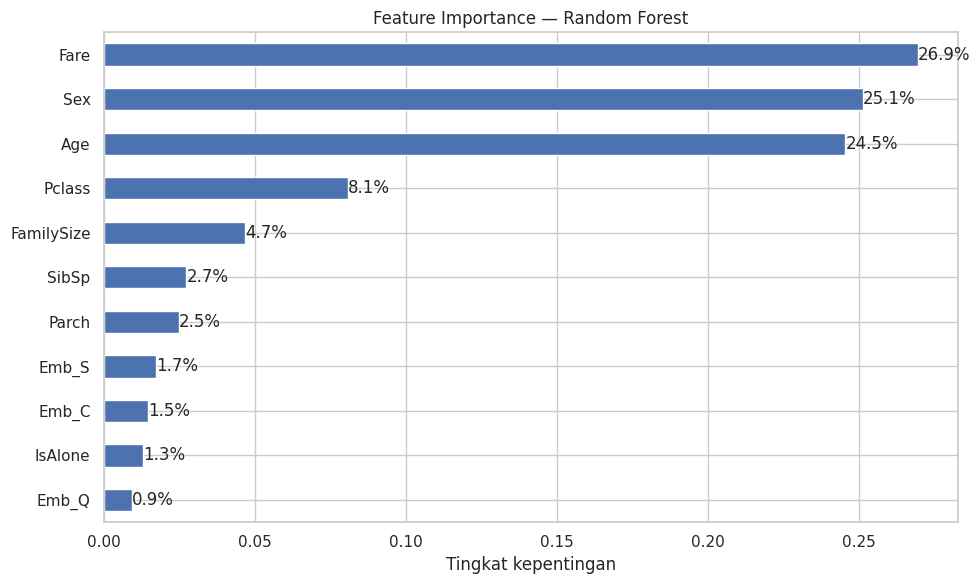

In [71]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importances.plot(kind="barh", color="#4C72B0")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Tingkat kepentingan")
for i, v in enumerate(importances):
    plt.text(v, i, f"{v*100:.1f}%", va="center")
plt.tight_layout()
plt.show()

Interpretasi:
- Tiga Faktor Paling Menentukan:
  - Fare (26.9%), Sex (25.1%), dan Age (24.5%) adalah tiga fitur yang paling dominan dan memiliki porsi kepentingan tertinggi dalam menentukan prediksi model (apakah penumpang selamat atau tidak). Ketiga variabel ini menyumbang lebih dari 76% total informasi yang diandalkan oleh model.

- Faktor Pendukung Menengah:
  - Pclass (8.1%) serta variabel keluarga seperti FamilySize (4.7%), SibSp (2.7%), dan Parch (2.5%) memberikan kontribusi tambahan yang cukup berarti bagi keputusan model.

- Faktor Pengaruh Kecil:
  - Fitur pelabuhan keberangkatan (Embarked) seperti Emb_S, Emb_C, Emb_Q, serta status IsAlone berada di bawah 2%, yang berarti fitur-fitur ini memiliki pengaruh yang paling kecil dalam proses klasifikasi model.

## Kesimpulan dan Insight




### 📌 Ringkasan Hasil Pemodelan
Dari eksperimen yang dilakukan menggunakan dua algoritma klasifikasi yang berbeda, berikut adalah perbandingan performa model pada data uji (test set):

1. **Logistic Regression (Dengan Scaling):**
   - **Akurasi:** **80.4%**
   - Model ini memiliki akurasi sedikit lebih tinggi dan sangat seimbang dalam mengenali penumpang yang selamat maupun meninggal.
   
2. **Random Forest (Tanpa Scaling):**
   - **Akurasi:** **79.9%**
   - Performa model ensemble berbasis pohon ini hampir setara dengan Logistic Regression, namun sedikit di bawahnya pada

### 💡 Insight Utama (Key Insights)

* **Faktor Gender dan Aturan "Women and Children First":**
  - Analisis koefisien pada Logistic Regression dan *feature importance* pada Random Forest menunjukkan bahwa **Sex (Jenis Kelamin)** merupakan salah satu prediktor paling dominan.
  - Perempuan memiliki tingkat kelolosan (survival rate) jauh lebih tinggi dibandingkan laki-laki, membuktikan berjalannya evakuasi prioritas saat tragedi terjadi.

* **Pengaruh Faktor Sosio-Ekonomi (Fare & Pclass):**
  - **Fare (Tarif tiket)** menempati posisi teratas pada tingkat kepentingan fitur di Random Forest (26.9%).
  - Penumpang di **Kelas 1 (Pclass 1)** memiliki peluang selamat yang jauh lebih besar dibandingkan penumpang Kelas 3. Status sosial ekonomi memainkan peran krusial dalam kemudahan akses ke sekoci penyelamat.

* **Faktor Demografi (Usia):**
  - **Usia (Age)** menjadi faktor penting ketiga. Kelompok usia anak-anak (sangat muda) tercatat memiliki rasio bertahan hidup yang lebih tinggi dibandingkan kelompok usia produktif dan lansia.

* **Dampak Hubungan Keluarga (Family Size):**
  - Bepergian bersama keluarga dalam jumlah kecil hingga sedang cenderung meningkatkan peluang bertahan hidup dibandingkan bepergian sendirian (*IsAlone*).

### 🛠️ Pelajaran Feature Engineering & Preprocessing
- **Pencegahan Data Leakage:** Melakukan pemisahan data (`train_test_split`) terlebih dahulu sebelum melakukan standardisasi (`StandardScaler`) adalah langkah krusial agar data uji tidak mempengaruhi proses pembelajaran model.
- **Penyederhanaan Fitur:** Menggabungkan kolom `SibSp` dan `Parch` menjadi `FamilySize` terbukti memberikan fitur baru yang bermakna dan memudahkan model menangkap pola hubungan sosial penumpang di kapal.